# Importing Libraries

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import numpy as np
import random
from itertools import product

#SPN Libraries and Functions
from spn.structure.StatisticalTypes import MetaType
from spn.structure.Base import Context, Sum, Product
from spn.structure.leaves.parametric.Parametric import Gaussian, Bernoulli
from spn.algorithms.Inference import log_likelihood
from spn.io.Graphics import plot_spn
from spn.structure.Base import assign_ids, rebuild_scopes_bottom_up

In [19]:
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Bayesian Network

In [20]:
#Structure of Bayesian Network
def gen_random_bayes(num_nodes=10, max_parents=2):
    nodes = [f'X{i}' for i in range(1, num_nodes + 1)]
    model = DiscreteBayesianNetwork()
    model.add_nodes_from(nodes)

    # Randomly add directed edges
    for child in nodes:
        possible_parents = [n for n in nodes if n != child]
        random.shuffle(possible_parents)
        num_parents = random.randint(0, min(max_parents, len(possible_parents)))
        parents_added = 0

        for parent in possible_parents:
            if parents_added >= num_parents:
                break
            try:
                model.add_edge(parent, child)
                parents_added += 1
            except ValueError:
                continue

    # Add random CPDs to BN
    cpds = []
    for node in model.nodes():
        parents = list(model.get_parents(node))
        parent_card = [2] * len(parents)
        num_combinations = np.prod(parent_card) if parent_card else 1
        values = np.random.rand(2, num_combinations)
        values /= values.sum(axis=0, keepdims=True)
        cpd = TabularCPD(
            variable=node, variable_card=2, values=values,
            evidence=parents if parents else None,
            evidence_card=parent_card if parents else None
        )
        cpds.append(cpd)

    model.add_cpds(*cpds)
    assert model.check_model(), "Model is invalid!"
    return model
bn = gen_random_bayes(num_nodes=15, max_parents=2)

In [21]:
#Print CPDs
print("\n=== Conditional Probability Distributions (CPDs) ===")
for cpd in bn.get_cpds():
    print(cpd)
    print("-" * 60)


=== Conditional Probability Distributions (CPDs) ===
+-------+----------+
| X1(0) | 0.282618 |
+-------+----------+
| X1(1) | 0.717382 |
+-------+----------+
------------------------------------------------------------
+-------+---------------------+--------------------+---------------------+---------------------+
| X4    | X4(0)               | X4(0)              | X4(1)               | X4(1)               |
+-------+---------------------+--------------------+---------------------+---------------------+
| X14   | X14(0)              | X14(1)             | X14(0)              | X14(1)              |
+-------+---------------------+--------------------+---------------------+---------------------+
| X2(0) | 0.9264836573629595  | 0.4086867363372556 | 0.20606486053294795 | 0.18053519301151216 |
+-------+---------------------+--------------------+---------------------+---------------------+
| X2(1) | 0.07351634263704049 | 0.5913132636627444 | 0.7939351394670521  | 0.8194648069884878  |
+---

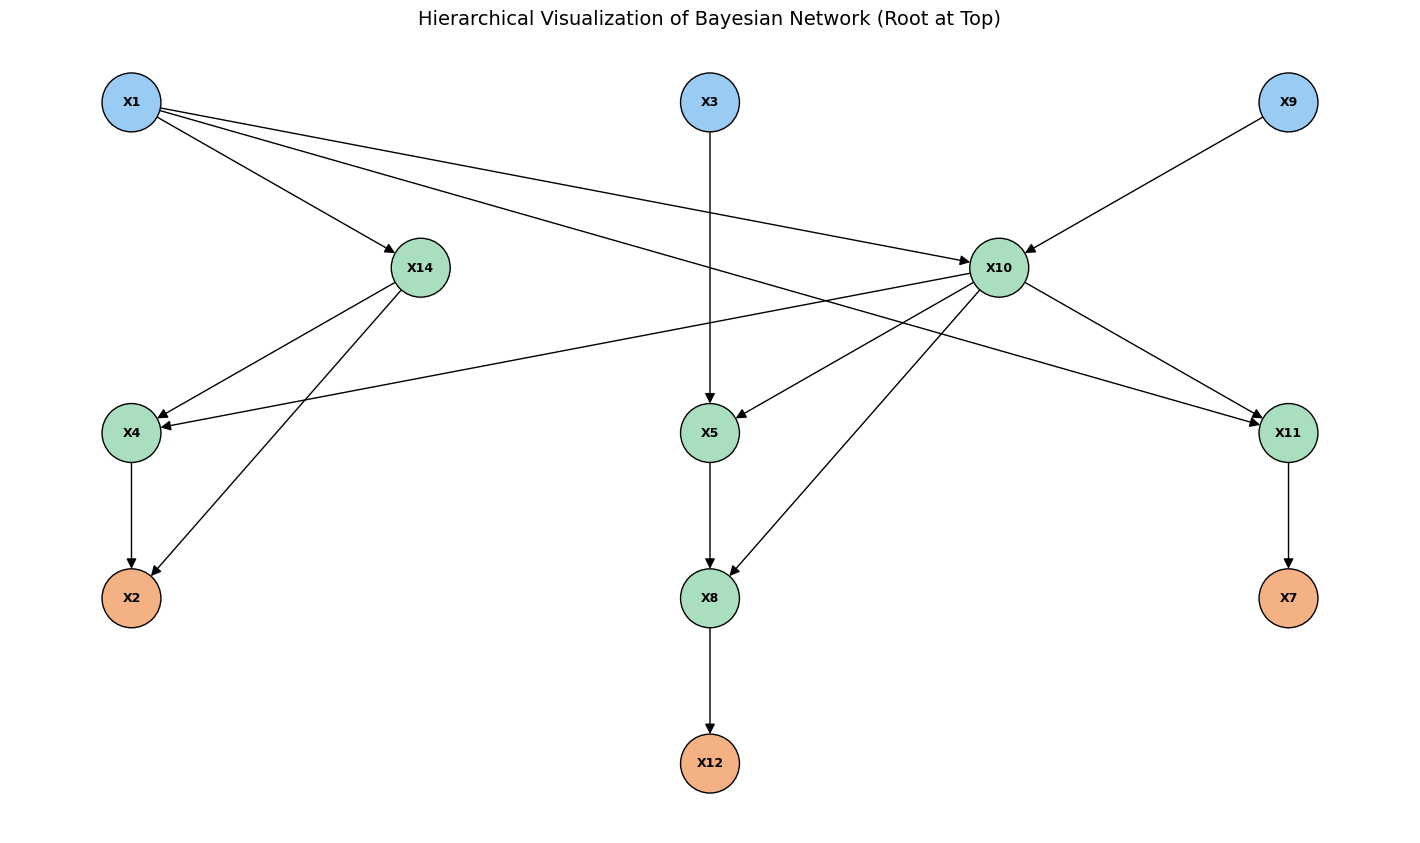

In [22]:
# Visualize the Bayesian Network
plt.figure(figsize=(14, 8))
G = nx.DiGraph(bn.edges())

# Compute node levels (for top-down layout)
levels = {}
for node in nx.topological_sort(G):
    parents = list(G.predecessors(node))
    if not parents:
        levels[node] = 0
    else:
        levels[node] = max(levels[p] for p in parents) + 1

# Arrange nodes by level (y position = -level)
pos = {}
layer_nodes = {}
for node, level in levels.items():
    layer_nodes.setdefault(level, []).append(node)

max_width = max(len(nodes) for nodes in layer_nodes.values())
for level, nodes in layer_nodes.items():
    n = len(nodes)
    for i, node in enumerate(nodes):
        pos[node] = (i - n / 2, -level)  # horizontally centered

# Color code: roots (blue), leaves (orange), intermediates (green)
roots = [n for n in G.nodes() if not list(G.predecessors(n))]
leaves = [n for n in G.nodes() if not list(G.successors(n))]
intermediates = [n for n in G.nodes() if n not in roots + leaves]

node_colors = []
for node in G.nodes():
    if node in roots:
        node_colors.append("#9ACBF3")   # blue
    elif node in leaves:
        node_colors.append("#F4B183")   # orange
    else:
        node_colors.append("#A9DFBF")   # green

nx.draw(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_color=node_colors,
    node_size=1800,
    font_size=9,
    font_weight="bold",
    edgecolors="black",
    arrowsize=15,
)

plt.title("Hierarchical Visualization of Bayesian Network (Root at Top)", fontsize=14)
plt.show()

# Inference

Variable Elimination

In [23]:
# inference of VariableElimination on BN
inference = VariableElimination(bn)
evidence = {"X2": 1, "X7": 1, "X15": 1}
query_result = inference.query(variables=["X1"], evidence=evidence)

# Display results
print("\nExact Inference using Variable Elimination:")
print(query_result)


Exact Inference using Variable Elimination:
+-------+-----------+
| X1    |   phi(X1) |
+=======+===========+
| X1(0) |    0.1749 |
+-------+-----------+
| X1(1) |    0.8251 |
+-------+-----------+


Sum Product Network

In [24]:
def bn_to_spn_exact(bn):
    """
    Converts a binary Bayesian Network (pgmpy) into an equivalent SPN using Bernoulli leaves.
    The SPN exactly represents the BN joint distribution.
    """

    # Sort nodes and create index mapping
    sorted_nodes = sorted(bn.nodes(), key=lambda x: str(x))
    node_to_idx = {node: idx for idx, node in enumerate(sorted_nodes)}

    variable_sum_nodes = []

    for node in sorted_nodes:
        cpd = bn.get_cpds(node)
        idx = node_to_idx[node]
        parents = list(cpd.get_evidence()) if cpd.get_evidence() is not None else []
        parent_indices = [node_to_idx[p] for p in parents]

        children = []
        weights = []

        if len(parents) == 0:
            # Root variable (no parents)
            p1 = float(cpd.get_value(**{node: 1}))
            p0 = 1.0 - p1

            child0 = Product(children=[Bernoulli(p=p0, scope=[idx])])
            child1 = Product(children=[Bernoulli(p=p1, scope=[idx])])
            children = [child0, child1]
            weights = [p0, p1]  # ✅ Properly normalized for the root node

        else:
            # For each parent configuration, build conditional Bernoulli leaves
            for pvals in product([0, 1], repeat=len(parents)):
                parent_assignment = {p: v for p, v in zip(parents, pvals)}
                p1 = float(cpd.get_value(**({node: 1, **parent_assignment})))
                p0 = 1.0 - p1

                # Parent context leaves
                parent_leaves = [
                    Bernoulli(p=1.0 if v == 1 else 0.0, scope=[pid])
                    for pid, v in zip(parent_indices, pvals)
                ]

                child0 = Product(children=[Bernoulli(p=p0, scope=[idx])] + parent_leaves)
                child1 = Product(children=[Bernoulli(p=p1, scope=[idx])] + parent_leaves)

                children.extend([child0, child1])
                weights.extend([p0, p1])  # ✅ use conditional probabilities

        # ✅ Normalize weights so that they sum to 1.0
        weights = np.array(weights, dtype=float)
        weights /= np.sum(weights)

        sum_node = Sum(children=children, weights=weights.tolist())
        variable_sum_nodes.append(sum_node)

    # Full SPN = product of all variable-level SPNs
    root = Product(children=variable_sum_nodes)
    rebuild_scopes_bottom_up(root)
    assign_ids(root)

    return root, node_to_idx


def spn_query_binary_exact(spn_root, mapping, query_var, evidence):
    """
    Performs inference P(query_var | evidence) using the constructed SPN.
    """
    nvars = len(mapping)
    base = np.full((1, nvars), np.nan)

    # Insert observed evidence into the SPN input
    for vname, val in evidence.items():
        base[0, mapping[vname]] = float(val)

    qidx = mapping[query_var]
    case0, case1 = base.copy(), base.copy()
    case0[0, qidx] = 0.0
    case1[0, qidx] = 1.0

    # Prepare two cases for the query variable
    data = np.vstack([case0, case1])

    # Compute log-likelihoods for both possible query values
    ll = log_likelihood(spn_root, data).reshape(-1)

    # Convert from log-space to normalized probability
    probs = np.exp(ll - np.max(ll))
    probs = probs / probs.sum()

    return {0: float(probs[0]), 1: float(probs[1])}

In [25]:
spn, mapping = bn_to_spn_exact(bn)

INFO:spn.io.Graphics:[ProductNode_0, SumNode_1, SumNode_2, SumNode_3, SumNode_4, SumNode_5, SumNode_6, SumNode_7, SumNode_8, SumNode_9, SumNode_10, SumNode_11, SumNode_12, SumNode_13, SumNode_14, SumNode_15, ProductNode_16, ProductNode_17, ProductNode_18, ProductNode_19, ProductNode_20, ProductNode_21, ProductNode_22, ProductNode_23, ProductNode_24, ProductNode_25, ProductNode_26, ProductNode_27, ProductNode_28, ProductNode_29, ProductNode_30, ProductNode_31, ProductNode_32, ProductNode_33, ProductNode_34, ProductNode_35, ProductNode_36, ProductNode_37, ProductNode_38, ProductNode_39, ProductNode_40, ProductNode_41, ProductNode_42, ProductNode_43, ProductNode_44, ProductNode_45, ProductNode_46, ProductNode_47, ProductNode_48, ProductNode_49, ProductNode_50, ProductNode_51, ProductNode_52, ProductNode_53, ProductNode_54, ProductNode_55, ProductNode_56, ProductNode_57, ProductNode_58, ProductNode_59, ProductNode_60, ProductNode_61, ProductNode_62, ProductNode_63, ProductNode_64, ProductN

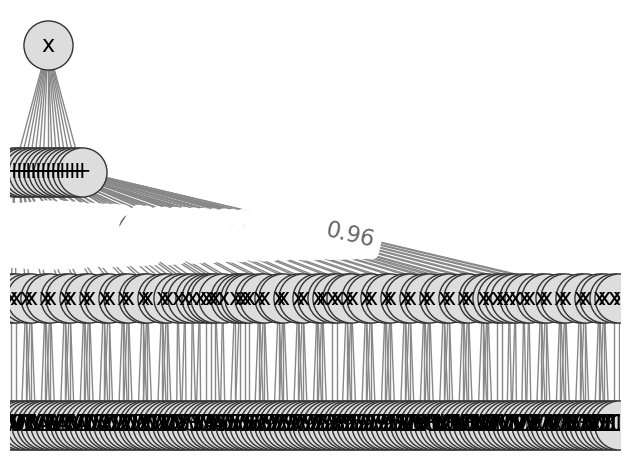

In [26]:
plot_spn(spn)

In [27]:
spn, mapping = bn_to_spn_exact(bn)

# Query: P(X1 | X2=1, X7=1, X15=1)
evidence = {"X2": 1, "X7": 1, "X15": 1}
result = spn_query_binary_exact(spn, mapping, "X1", evidence)

print("\nSPN Inference Result:")
print(f"P(X1=0 | evidence) = {result[0]:.4f}")
print(f"P(X1=1 | evidence) = {result[1]:.4f}")


SPN Inference Result:
P(X1=0 | evidence) = 0.4055
P(X1=1 | evidence) = 0.5945


In [28]:
evidence = {"X2": 1, "X7": 1, "X15": 1}

result = spn_query_binary_exact(spn, mapping, "X1", evidence)

print("\nExact Inference using SPN:")
print(f"P(X1=0 | evidence) = {result[0]:.6f}")
print(f"P(X1=1 | evidence) = {result[1]:.6f}")


Exact Inference using SPN:
P(X1=0 | evidence) = 0.405490
P(X1=1 | evidence) = 0.594510
